In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import datetime


from src.analytics.aws_function_logs import AWSFunctionLogs
from src.profiler.config_manager import ConfigManager
from src.profiler.explorer import Explorer
from src.profiler.cost_calculator import CostCalculator
from src.application.step_functions import StepFunctions

from src.modeling.function_performance_modeling import FunctionPerformanceModeling

In [ ]:
payload = "{\"images\":[], \"batch_size\":4, \"use_random_image\":true, \"num_random_images\":8, \"model_name\":\"resnet-152\"}"
region_name = 'us-east-1'

memeory_bounds = (1000, 6000)
memory_space_step = 64

function_name = f'sam-ml-InferenceFunctionResnet-W96qjSQGg3Ix'
p_model = FunctionPerformanceModeling(function_name=function_name, payload=payload, memory_bounds=memeory_bounds)
o_memory = p_model.get_optimal_memory()
print(f'Optimal memory for {function_name} is {o_memory}')
ConfigManager(function_name=function_name, boto_session=boto3.Session(region_name=region_name)).set_config(o_memory)
duration_per_memory = p_model.get_performance_model_as_function()
del p_model


2025-03-27 18:52:34 - src.utils.logger - WARNING - Lambda exploration timed out. sam-ml-InferenceFunctionResnet-W96qjSQGg3Ix: 128MB
2025-03-27 18:52:34 - src.utils.logger - ERROR - Function timed out. The execution time limit is reached
2025-03-27 18:52:34 - src.utils.logger - ERROR - Function timed out. The execution time limit is reached


In [3]:
explorer = Explorer(
    function_name=function_name,
    payload=payload,
    boto_session=boto3.Session(region_name=region_name),
    memory_space_step=memory_space_step,
    max_invocations=5
)

explorer.explore_all_memories(num_of_invocations=5)

Processing: 100%|██████████ [Elapsed: 05:50 | Remaining: 00:00]


In [5]:
df = AWSFunctionLogs(
    boto_session=boto3.Session(region_name=region_name),
    function_name=function_name,
).get_logs_df(start_time=int((datetime.datetime.utcnow() - datetime.timedelta(days=1)).timestamp()),
    end_time=int(datetime.datetime.utcnow().timestamp()))

df.to_csv(f'{function_name}_logs.csv')

/var/folders/59/lmfb_dpj21jfmr37qw9yp81r0000gn/T/ipykernel_80684/4178548919.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ).get_logs_df(start_time=int((datetime.datetime.utcnow() - datetime.timedelta(days=1)).timestamp()),
/var/folders/59/lmfb_dpj21jfmr37qw9yp81r0000gn/T/ipykernel_80684/4178548919.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_time=int(datetime.datetime.utcnow().timestamp()))


In [6]:
config_manager = ConfigManager(function_name=function_name, boto_session=boto3.Session(region_name=region_name))
config_manager.set_config(5000)

print(config_manager.get_config())

FunctionConfig(memory_mb=5000, timeout_s=900)


In [7]:
cost_calculator = CostCalculator(
    function_name=function_name,
)

In [8]:
df = pd.read_csv(f'{function_name}_logs.csv')

In [9]:
logs = df[df['Init Duration'].isna()]

logs = logs.groupby('Memory Size').agg({
    'Duration': 'mean',
}).reset_index()

if 'Duration' in logs.columns and 'Memory Size' in logs.columns:
    # Calculate the cost using .loc to avoid SettingWithCopyWarning
    logs.loc[:, 'Cost'] = logs.apply(
        lambda row: cost_calculator.calculate_cost(
            memory_mb=row['Memory Size'],
            duration_ms=row['Duration']
        ),
        axis=1
    )


In [ ]:
memory_space = np.arange(memeory_bounds[0], memeory_bounds[1] + 1)

logs = logs[logs['Memory Size'].isin(memory_space)]

modeled_duration = []
modeled_cost = []

for memory in memory_space:
    t = duration_per_memory(memory)
    modeled_duration.append(t)
    modeled_cost.append(cost_calculator.calculate_cost(memory_mb=memory, duration_ms=t))

modeled_duration = np.array(modeled_duration)
modeled_cost = np.array(modeled_cost)

In [12]:
logs

,Memory Size,Duration,Cost
0,128.0,3081.184444,0.000007
1,192.0,2046.396000,0.000007
2,256.0,1494.378000,0.000006
3,320.0,1337.708000,0.000007
4,384.0,1102.722000,0.000007
5,448.0,950.182000,0.000007
6,512.0,829.996000,0.000007
7,576.0,667.648000,0.000006
8,640.0,614.178000,0.000007
9,672.0,591.462500,0.000007


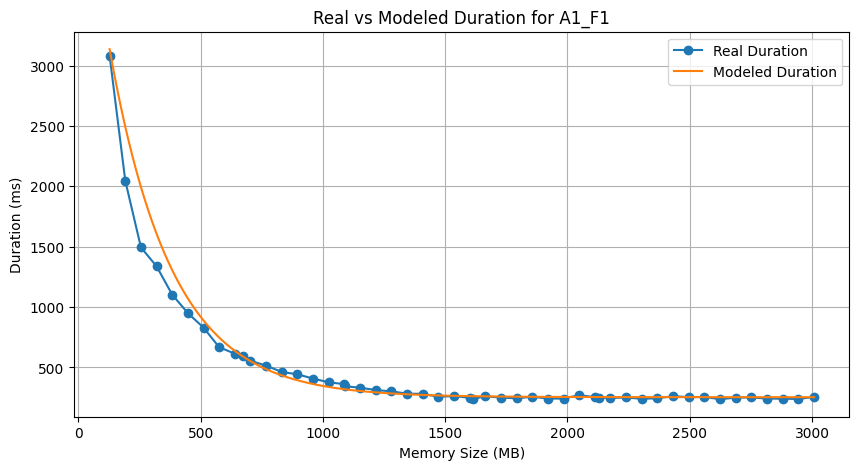

In [ ]:
# Real vs Modeled Duration
plt.figure(figsize=(10, 5))
plt.plot(logs['Memory Size'], logs['Duration'], label='Real Duration', marker='o')
plt.plot(memory_space, modeled_duration, label='Modeled Duration')
plt.xlabel('Memory Size (MB)')
plt.ylabel('Duration (ms)')
plt.title(f'Real vs Modeled Duration for {function_name}')
plt.legend()
plt.grid()

plt.show()

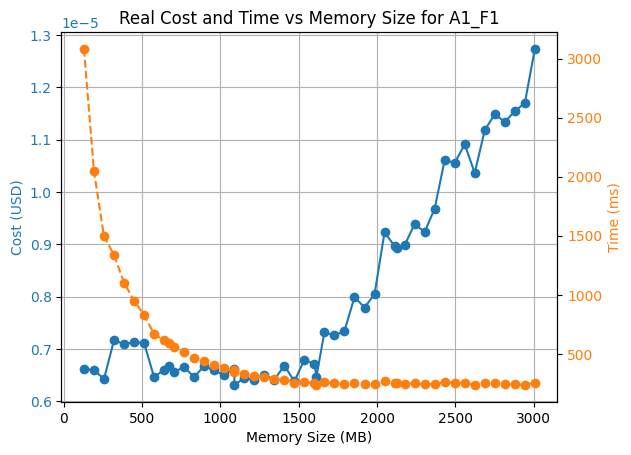

In [14]:
# Create figure and axis objects
fig, ax1 = plt.subplots()

# Plot Cost on the primary y-axis
ax1.set_xlabel('Memory Size (MB)')
ax1.set_ylabel('Cost (USD)', color='tab:blue')
ax1.plot(logs['Memory Size'], logs['Cost'], color='tab:blue', marker='o', label='Cost')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for Time
ax2 = ax1.twinx()
ax2.set_ylabel('Time (ms)', color='tab:orange')
ax2.plot(logs['Memory Size'], logs['Duration'], color='tab:orange', marker='o', linestyle='--', label='Time')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add a title and grid
plt.title('Real Cost and Time vs Memory Size for ' + function_name)
ax1.grid(True)

# Show plot
plt.show()

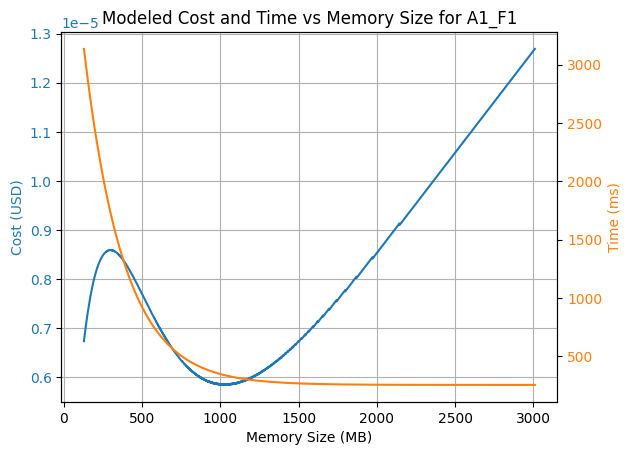

In [ ]:
# Create figure and axis objects
fig, ax1 = plt.subplots()


# Plot Cost on the primary y-axis
ax1.set_xlabel('Memory Size (MB)')
ax1.set_ylabel('Cost (USD)', color='tab:blue')
ax1.plot(memory_space, modeled_cost, color='tab:blue', label='Cost')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for Time
ax2 = ax1.twinx()
ax2.set_ylabel('Time (ms)', color='tab:orange')
ax2.plot(memory_space, modeled_duration, color='tab:orange', label='Time')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Add a title and grid
plt.title('Modeled Cost and Time vs Memory Size for ' + function_name)
ax1.grid(True)

# Show plot
plt.show()